# Student Performance Prediction System using Machine Learning

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("dataset/Student_performance_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print(df.head())

   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1             0  3

In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (2392, 15)


In [6]:
print("Column names:")
print(df.columns)

Column names:
Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='str')


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [9]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [10]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [11]:
df = df.drop(columns=["StudentID"])

print("Student ID removed.")

Student ID removed.


In [12]:
df = df.drop_duplicates()

print("Duplicate rows removed.")
print("Dataset shape:", df.shape)

Duplicate rows removed.
Dataset shape: (2392, 14)


In [13]:
print("Missing values after preprocessing:")

print(df.isnull().sum())

Missing values after preprocessing:
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


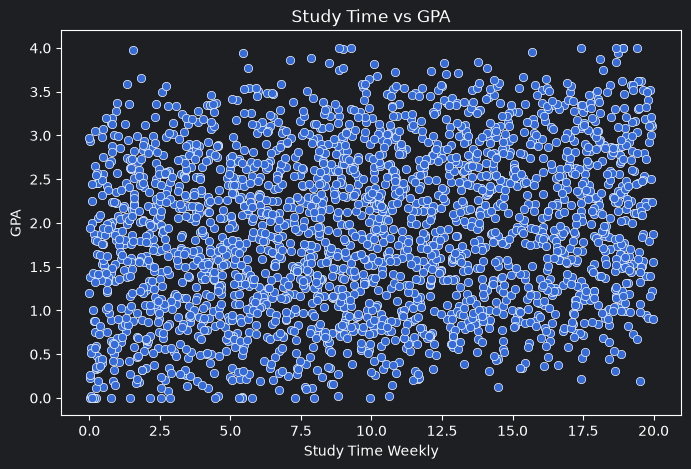

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df,x="StudyTimeWeekly",y="GPA")

plt.title("Study Time vs GPA")

plt.xlabel("Study Time Weekly")

plt.ylabel("GPA")

plt.show()

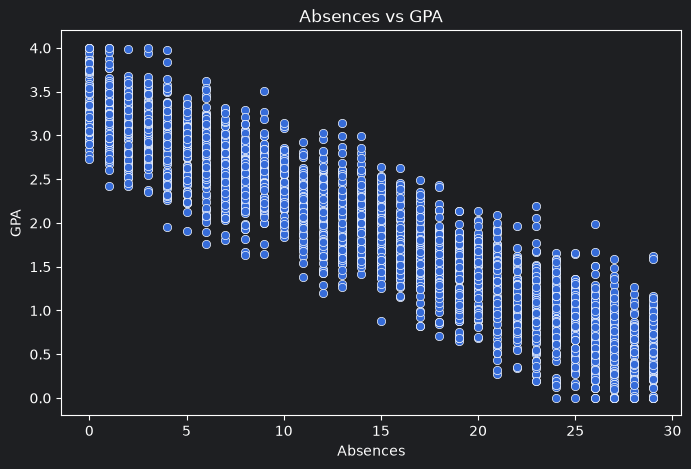

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df,x="Absences",y="GPA")

plt.title("Absences vs GPA")

plt.xlabel("Absences")

plt.ylabel("GPA")

plt.show()

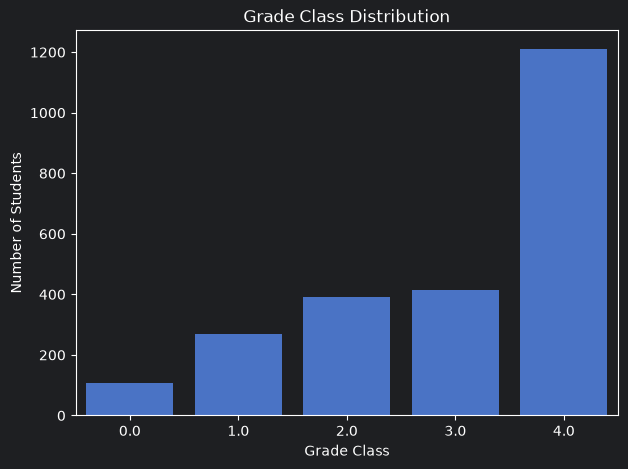

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df,x="GradeClass")

plt.title("Grade Class Distribution")

plt.xlabel("Grade Class")

plt.ylabel("Number of Students")

plt.show()

In [17]:
features = [
    "Age",
    "Gender",
    "Ethnicity",
    "ParentalEducation",
    "StudyTimeWeekly",
    "Absences",
    "Tutoring",
    "ParentalSupport",
    "Extracurricular",
    "Sports",
    "Music",
    "Volunteering"
]

X = df[features]

y = df["GradeClass"]

print("Features selected:")
print(X.columns)

Features selected:
Index(['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly',
       'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports',
       'Music', 'Volunteering'],
      dtype='str')


In [18]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2392, 12)
y shape: (2392,)


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)


print("Training data:", X_train.shape)

print("Testing data:", X_test.shape)

Training data: (1913, 12)
Testing data: (479, 12)


In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
from sklearn.tree import DecisionTreeClassifier

In [23]:
from sklearn.svm import SVC

In [24]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train,y_train)

print("Logistic Regression trained.")

Logistic Regression trained.


In [25]:
decision_tree_model = DecisionTreeClassifier( random_state=42)

decision_tree_model.fit(X_train,y_train)

print("Decision Tree trained.")

Decision Tree trained.


In [27]:
from sklearn.naive_bayes import GaussianNB

In [28]:
naive_bayes_model = GaussianNB()

naive_bayes_model.fit(X_train, y_train)

print("Naive Bayes: Trained")

Naive Bayes: Trained


In [29]:
svm_model = SVC()

svm_model.fit(X_train,y_train)

print("SVM trained.")

SVM trained.


In [30]:
logistic_pred = logistic_model.predict(X_test)


decision_tree_pred = decision_tree_model.predict( X_test)


naive_bayes_pred = naive_bayes_model.predict(X_test)


svm_pred = svm_model.predict(X_test)



print("Predictions completed.")

Predictions completed.


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [32]:
print(" ACCURACY ")

print("Logistic Regression:",accuracy_score(y_test, logistic_pred))


print("Decision Tree:",accuracy_score(y_test, decision_tree_pred))


print("Naive Bayes:",accuracy_score(y_test, naive_bayes_pred))

print("SVM:",accuracy_score(y_test, svm_pred))

 ACCURACY 
Logistic Regression: 0.7265135699373695
Decision Tree: 0.5803757828810021
Naive Bayes: 0.6722338204592901
SVM: 0.7306889352818372


In [33]:
print(" PRECISION ")


print("Logistic Regression:",precision_score(y_test,logistic_pred,average="weighted",zero_division=0))


print("Decision Tree:",precision_score(y_test,decision_tree_pred,average="weighted",zero_division=0))


print("Naive Bayes:", precision_score(y_test,naive_bayes_pred,average="weighted",zero_division=0))


print("SVM:",precision_score(y_test,svm_pred,average="weighted",zero_division=0))

 PRECISION 
Logistic Regression: 0.7145458585930136
Decision Tree: 0.6126040209548544
Naive Bayes: 0.6646930512127437
SVM: 0.699729019661847


In [35]:
print(" RECALL")


print("Logistic Regression:",recall_score(y_test,logistic_pred,average="weighted",zero_division=0))


print("Decision Tree:",recall_score(y_test,decision_tree_pred,average="weighted",zero_division=0))


print("Naive Bayes:",recall_score(y_test,naive_bayes_pred,average="weighted",zero_division=0))


print("SVM:",recall_score(y_test,svm_pred,average="weighted",zero_division=0))

 RECALL
Logistic Regression: 0.7265135699373695
Decision Tree: 0.5803757828810021
Naive Bayes: 0.6722338204592901
SVM: 0.7306889352818372


In [36]:
print(" F1 SCORE ")


print("Logistic Regression:",f1_score( y_test,logistic_pred, average="weighted",zero_division=0))


print("Decision Tree:",f1_score(y_test, decision_tree_pred,average="weighted", zero_division=0))


print("Naive Bayes:",f1_score( y_test,naive_bayes_pred,average="weighted",zero_division=0))


print("SVM:",f1_score(y_test,svm_pred,average="weighted",zero_division=0))

 F1 SCORE 
Logistic Regression: 0.7148326406749812
Decision Tree: 0.59310510722032
Naive Bayes: 0.6526536610620574
SVM: 0.7141066237806367


In [37]:
print("Logistic Regression:")

print(confusion_matrix(y_test,logistic_pred))

Logistic Regression:
[[  3   7   3   4   4]
 [  6  23  20   3   2]
 [  0  10  53  12   3]
 [  0   0  27  39  17]
 [  0   3   1   9 230]]


In [38]:
print("Decision Tree:")

print(confusion_matrix(y_test,decision_tree_pred))

Decision Tree:
[[  5   6   2   3   5]
 [  6  28  10   6   4]
 [  4  22  30  18   4]
 [  2   5  26  33  17]
 [  6  14  10  31 182]]


In [39]:
print("Naive Bayes:")

print(confusion_matrix(y_test,naive_bayes_pred))

Naive Bayes:
[[  1   8   5   3   4]
 [  1  13  34   4   2]
 [  0  11  53  11   3]
 [  0   4  29  30  20]
 [  0   2   3  13 225]]


In [40]:
print("SVM:")

print(confusion_matrix(y_test,svm_pred))

SVM:
[[  0  11   2   3   5]
 [  0  26  22   4   2]
 [  0  10  50  15   3]
 [  0   0  20  47  16]
 [  0   3   0  13 227]]


In [41]:
logistic_accuracy = accuracy_score(y_test, logistic_pred)

decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)

naive_bayes_accuracy = accuracy_score(y_test, naive_bayes_pred)

svm_accuracy = accuracy_score(y_test, svm_pred)


In [42]:
accuracies = {
    "Logistic Regression": logistic_accuracy,
    "Decision Tree": decision_tree_accuracy,
    "Naive Bayes": naive_bayes_accuracy,
    "SVM": svm_accuracy
              }


best_model_name = max(accuracies, key=accuracies.get)


print("Best Model:", best_model_name)

print("Best Accuracy:", accuracies[best_model_name])


Best Model: SVM
Best Accuracy: 0.7306889352818372


In [43]:
sample_student = X_test.iloc[[0]]

print(sample_student)

      Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  \
1167   16       1          0                  1         9.355165        18   

      Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering  
1167         0                3                1       0      0             1  


In [44]:
best_model = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Naive Bayes": naive_bayes_model,
    "SVM": svm_model
}[best_model_name]

prediction = best_model.predict(sample_student)

print("Predicted Grade Class:", prediction[0])

Predicted Grade Class: 4.0


In [45]:
import joblib
import os

In [46]:
os.makedirs("model", exist_ok=True)


In [47]:
joblib.dump(best_model, "model/student_performance_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.
